# 03. Decremento logarítmico y estimación del amortiguamiento

Este cuaderno introduce el método del **decremento logarítmico** para estimar la razón de amortiguamiento $\zeta$ y el coeficiente de amortiguamiento viscoso $c$ a partir de una señal de vibración libre amortiguada.

El objetivo es comprender:

1. cómo decae la amplitud de una vibración libre amortiguada;
2. cómo detectar máximos sucesivos de la señal;
3. cómo calcular el decremento logarítmico;
4. cómo estimar la razón de amortiguamiento $\zeta$;
5. cómo calcular el coeficiente de amortiguamiento viscoso $c$;
6. cómo comparar valores teóricos y estimados.

Este notebook es útil tanto para estudiantes de vibraciones como para introducir conceptos relevantes en análisis modal experimental y monitoreo estructural.

## 1. Importar librerías

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

print("Ambiente listo para estudiar decremento logarítmico")

Ambiente listo para estudiar decremento logarítmico


## 2. Modelo de vibración libre amortiguada

Para un sistema masa–resorte–amortiguador de un grado de libertad, la ecuación de movimiento libre es:

$
m\ddot{x}(t) + c\dot{x}(t) + kx(t) = 0
$

Para un sistema subamortiguado, es decir $0 < \zeta < 1$, una solución típica es:

$
x(t) = X_0 e^{-\zeta \omega_n t}\cos(\omega_d t)
$

donde:

- $X_0$ es el desplazamiento inicial;
- $\zeta$ es la razón de amortiguamiento;
- $\omega_n$ es la frecuencia natural no amortiguada;
- $\omega_d$ es la frecuencia natural amortiguada.

La frecuencia natural angular no amortiguada es:

$
\omega_n = \sqrt{\frac{k}{m}}
$

y la frecuencia amortiguada es:

$
\omega_d = \omega_n\sqrt{1-\zeta^2}
$

In [13]:
# Parámetros físicos del sistema
mass = 10.0          # kg
stiffness = 4000.0   # N/m
zeta_true = 0.04     # razón de amortiguamiento verdadera

# Parámetros de simulación
sampling_frequency = 200.0  # Hz
duration = 20.0             # s
initial_displacement = 0.01 # m

# Cálculos teóricos
omega_n = np.sqrt(stiffness / mass)
fn_hz = omega_n / (2 * np.pi)

omega_d = omega_n * np.sqrt(1 - zeta_true**2)
fd_hz = omega_d / (2 * np.pi)

c_true = 2 * zeta_true * mass * omega_n

print(f"Masa m = {mass:.2f} kg")
print(f"Rigidez k = {stiffness:.2f} N/m")
print(f"Razón de amortiguamiento verdadera zeta = {zeta_true:.4f}")
print(f"Frecuencia natural fn = {fn_hz:.3f} Hz")
print(f"Frecuencia amortiguada fd = {fd_hz:.3f} Hz")
print(f"Coeficiente de amortiguamiento verdadero c = {c_true:.3f} N s/m")

Masa m = 10.00 kg
Rigidez k = 4000.00 N/m
Razón de amortiguamiento verdadera zeta = 0.0400
Frecuencia natural fn = 3.183 Hz
Frecuencia amortiguada fd = 3.181 Hz
Coeficiente de amortiguamiento verdadero c = 16.000 N s/m


## 3. Generar una señal de vibración libre amortiguada

Generaremos una señal limpia y luego una señal con ruido leve, para parecerse más a una medición experimental.

In [14]:
rng = np.random.default_rng(42)

t = np.arange(0, duration, 1 / sampling_frequency)

x_clean = initial_displacement * np.exp(-zeta_true * omega_n * t) * np.cos(omega_d * t)

noise_level = 0.015
noise = rng.normal(
    loc=0.0,
    scale=noise_level * np.max(np.abs(x_clean)),
    size=len(t)
)

x_noisy = x_clean + noise

print(f"Número de muestras: {len(t)}")
print(f"Duración de la señal: {duration} s")
print(f"Frecuencia de muestreo: {sampling_frequency} Hz")

Número de muestras: 4000
Duración de la señal: 20.0 s
Frecuencia de muestreo: 200.0 Hz


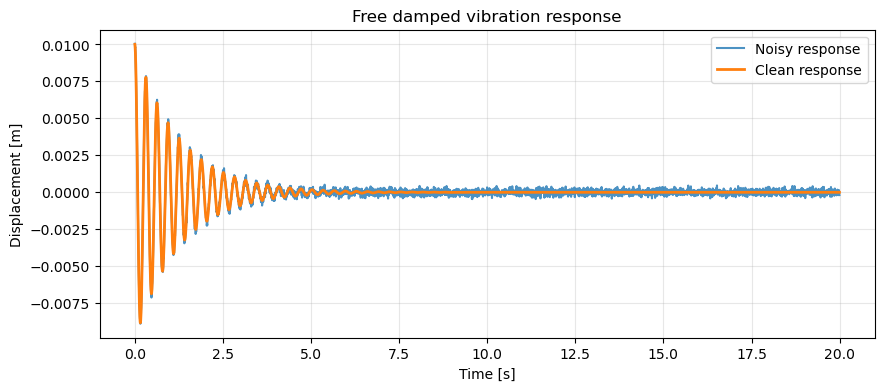

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(t, x_noisy, label="Noisy response", alpha=0.8)
plt.plot(t, x_clean, linewidth=2, label="Clean response")
plt.title("Free damped vibration response")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4. Decremento logarítmico

El decremento logarítmico mide cuánto disminuye la amplitud entre máximos sucesivos de una vibración libre amortiguada.

Si usamos dos máximos positivos separados por \(n\) ciclos:

$
\delta = \frac{1}{n}\ln\left(\frac{x_i}{x_{i+n}}\right)
$

donde:

- $x_i$ es un máximo de la señal;
- $x_{i+n}$ es otro máximo después de $n$ ciclos;
- $n$ es el número de ciclos entre ambos máximos.

Luego, para un sistema subamortiguado, la razón de amortiguamiento se estima como:

$
\zeta = \frac{\delta}{\sqrt{4\pi^2 + \delta^2}}
$

## 5. Detectar máximos de la señal

Usaremos `find_peaks` para detectar los máximos positivos de la señal.  
En señales experimentales, esta etapa puede requerir ajustar parámetros como la distancia mínima entre peaks o la prominencia.

In [16]:
# Distancia mínima esperada entre peaks
# Si la frecuencia amortiguada es fd_hz, el período amortiguado es aproximadamente 1/fd_hz.
# Convertimos ese período a muestras.
period_samples = int((1 / fd_hz) * sampling_frequency)

peaks, properties = find_peaks(
    x_noisy,
    distance=int(0.7 * period_samples),
    prominence=0.0002
)

peak_times = t[peaks]
peak_values = x_noisy[peaks]

# Nos quedamos solo con peaks positivos
positive_mask = peak_values > 0
peak_times = peak_times[positive_mask]
peak_values = peak_values[positive_mask]
peaks = peaks[positive_mask]

print(f"Número de máximos positivos detectados: {len(peak_values)}")
print(f"Período amortiguado teórico aproximado: {1/fd_hz:.3f} s")
print(f"Distancia mínima usada: {int(0.7 * period_samples)} muestras")

Número de máximos positivos detectados: 66
Período amortiguado teórico aproximado: 0.314 s
Distancia mínima usada: 43 muestras


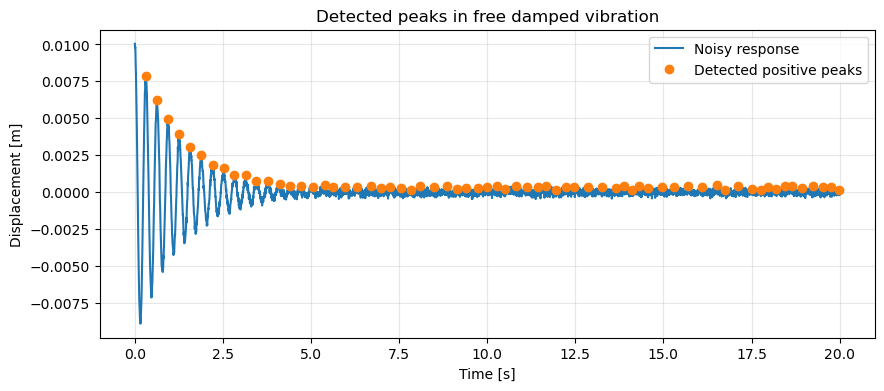

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(t, x_noisy, label="Noisy response")
plt.plot(peak_times, peak_values, "o", label="Detected positive peaks")
plt.title("Detected peaks in free damped vibration")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Estimar $\delta$, $\zeta$ y $c$

Para mejorar la estimación, no usaremos necesariamente peaks consecutivos.  
Usaremos dos máximos separados por varios ciclos, porque así el decaimiento acumulado es más claro.

En este ejemplo tomaremos:

$
x_i = x_1
$

y

$
x_{i+n} = x_{1+n}
$

con $n = 5$ ciclos, siempre que existan suficientes peaks detectados.

In [18]:
# Selección de peaks para el cálculo
i = 0
n_cycles = 5

if len(peak_values) <= n_cycles:
    raise ValueError("No hay suficientes peaks detectados para aplicar el decremento logarítmico.")

x_i = peak_values[i]
x_i_n = peak_values[i + n_cycles]

t_i = peak_times[i]
t_i_n = peak_times[i + n_cycles]

delta_est = (1 / n_cycles) * np.log(x_i / x_i_n)

zeta_est = delta_est / np.sqrt(4 * np.pi**2 + delta_est**2)

omega_n_est = omega_d / np.sqrt(1 - zeta_est**2)
c_est = 2 * zeta_est * mass * omega_n_est

print("Estimación por decremento logarítmico")
print("--------------------------------------")
print(f"x_i = {x_i:.6f} m en t = {t_i:.3f} s")
print(f"x_i+n = {x_i_n:.6f} m en t = {t_i_n:.3f} s")
print(f"Número de ciclos n = {n_cycles}")
print(f"Decremento logarítmico delta = {delta_est:.5f}")
print(f"zeta estimado = {zeta_est:.5f}")
print(f"c estimado = {c_est:.3f} N s/m")

Estimación por decremento logarítmico
--------------------------------------
x_i = 0.007860 m en t = 0.315 s
x_i+n = 0.002522 m en t = 1.875 s
Número de ciclos n = 5
Decremento logarítmico delta = 0.22733
zeta estimado = 0.03616
c estimado = 14.461 N s/m


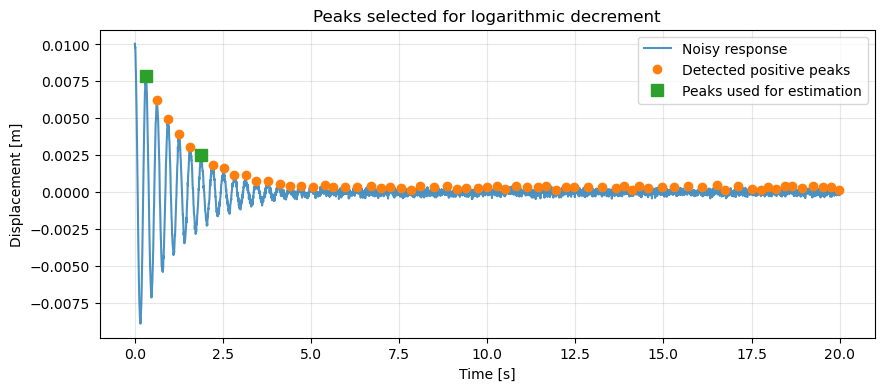

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(t, x_noisy, label="Noisy response", alpha=0.8)
plt.plot(peak_times, peak_values, "o", label="Detected positive peaks")
plt.plot([t_i, t_i_n], [x_i, x_i_n], "s", markersize=9, label="Peaks used for estimation")
plt.title("Peaks selected for logarithmic decrement")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 7. Comparación entre valores reales y estimados

Ahora compararemos los valores usados para generar la señal con los valores estimados a partir de la respuesta temporal.

In [20]:
error_zeta_percent = 100 * abs(zeta_est - zeta_true) / zeta_true
error_c_percent = 100 * abs(c_est - c_true) / c_true

print("Comparación")
print("-----------")
print(f"zeta verdadero : {zeta_true:.5f}")
print(f"zeta estimado  : {zeta_est:.5f}")
print(f"Error zeta     : {error_zeta_percent:.2f} %")
print()
print(f"c verdadero    : {c_true:.3f} N s/m")
print(f"c estimado     : {c_est:.3f} N s/m")
print(f"Error c        : {error_c_percent:.2f} %")

Comparación
-----------
zeta verdadero : 0.04000
zeta estimado  : 0.03616
Error zeta     : 9.61 %

c verdadero    : 16.000 N s/m
c estimado     : 14.461 N s/m
Error c        : 9.62 %


## 8. Envolvente exponencial

La amplitud de una vibración libre amortiguada está modulada por una envolvente exponencial:

$
\pm X_0 e^{-\zeta \omega_n t}
$

Graficaremos la señal junto con su envolvente teórica y una envolvente estimada usando $\zeta$ obtenido por decremento logarítmico.

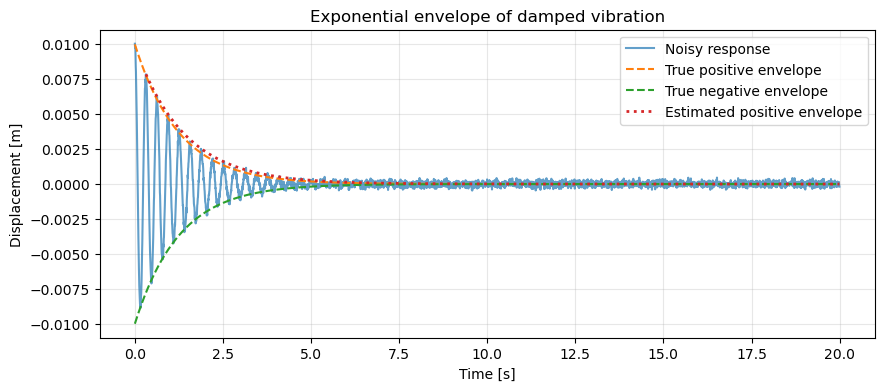

In [21]:
envelope_true = initial_displacement * np.exp(-zeta_true * omega_n * t)
envelope_est = x_i * np.exp(-zeta_est * omega_n_est * (t - t_i))

# Para evitar que la envolvente estimada se dibuje antes del primer peak usado
envelope_est[t < t_i] = np.nan

plt.figure(figsize=(10, 4))
plt.plot(t, x_noisy, label="Noisy response", alpha=0.7)
plt.plot(t, envelope_true, "--", label="True positive envelope")
plt.plot(t, -envelope_true, "--", label="True negative envelope")
plt.plot(t, envelope_est, ":", linewidth=2, label="Estimated positive envelope")
plt.title("Exponential envelope of damped vibration")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 9. ¿Qué pasa si cambia el amortiguamiento?

Ahora repetiremos la simulación para distintos valores de $\zeta$.  
Esto permite visualizar cómo el amortiguamiento controla la velocidad con que decae la vibración.

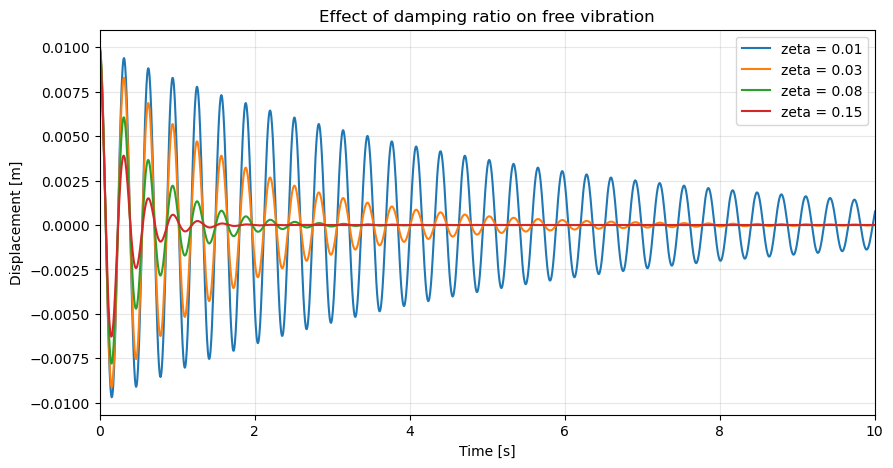

In [22]:
zeta_values = [0.01, 0.03, 0.08, 0.15]

plt.figure(figsize=(10, 5))

for zeta in zeta_values:
    omega_d_local = omega_n * np.sqrt(1 - zeta**2)
    x_local = initial_displacement * np.exp(-zeta * omega_n * t) * np.cos(omega_d_local * t)
    plt.plot(t, x_local, label=f"zeta = {zeta:.2f}")

plt.title("Effect of damping ratio on free vibration")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.xlim(0, 10)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 10. Interpretación

El decremento logarítmico permite estimar amortiguamiento a partir del decaimiento de la amplitud en una vibración libre.

La idea física es simple:

> mientras mayor es el amortiguamiento, más rápido desaparece la vibración.

En términos prácticos:

- si los máximos sucesivos decaen lentamente, $\zeta$ es pequeño;
- si los máximos decaen rápidamente, $\zeta$ es mayor;
- si conocemos masa y rigidez, podemos estimar el coeficiente viscoso $c$;
- si trabajamos con señales experimentales, la detección de peaks puede ser sensible al ruido.

Este método es clásico y muy útil para conectar teoría de vibraciones con señales medidas.

## 11. Preguntas para estudiantes

1. ¿Por qué usamos el logaritmo del cociente entre amplitudes?
2. ¿Qué ocurre con el decremento logarítmico si el amortiguamiento aumenta?
3. ¿Por qué puede ser conveniente usar peaks separados por varios ciclos?
4. ¿Qué problemas aparecen si la señal tiene mucho ruido?
5. ¿Qué información necesitamos para calcular \(c\), además de \(\zeta\)?
6. ¿Qué diferencia hay entre frecuencia natural no amortiguada y frecuencia amortiguada?
7. ¿Cómo podríamos aplicar este método a una señal medida con un acelerómetro?

In [23]:
# Experimento sugerido:
# Cambia zeta_true, noise_level y n_cycles.
# Observa cómo cambian los errores de estimación de zeta y c.